# JWST/MIRI SN1983V Photometry Notebook

### MIRI Filters: F770W, F1000W, F1130W, F2100W
### NIRcam Filters: F200W, F300M, F330M, F360M

- Written by Justin Pierel
- Edited / Formatted by Sophie Kressy

In [1]:
%matplotlib inline

#### make sure to update working directory


In [2]:
import sys,os,glob,shutil
import tarfile, urllib.request

# update this path to your working directory!!
os.environ["STPSF_PATH"] = '/Users/sophiakressy/Library/Mobile Documents/com~apple~CloudDocs/Desktop/VS_Workspace/sn_dust/stpsf-data/stpsf-data/'
os.environ["PYSYN_CDBS"] = "/Users/sophiakressy/Library/Mobile Documents/com~apple~CloudDocs/Desktop/VS_Workspace/sn_dust/grp"

# WEBBPSF Data
#boxlink = 'https://stsci.box.com/shared/static/qxpiaxsjwo15ml6m4pkhtk36c9jgj70k.gz'  
boxlink = 'https://stsci.box.com/shared/static/kqfolg2bfzqc4mjkgmujo06d3iaymahv.gz'
#boxfile = './webbpsf-data/webbpsf-data-1.0.0.tar.gz'
boxfile = './stpsf-data/stpsf-data-LATEST.tar.gz'
synphot_url = 'http://ssb.stsci.edu/trds/tarfiles/synphot5.tar.gz'
synphot_file = './synphot5.tar.gz'

#webbpsf_folder = './webbpsf-data'
stpsf_folder = "./stpsf-data"
synphot_folder = './grp'

# Gather webbpsf files
#psfExist = os.path.exists(webbpsf_folder)
psfExist = os.path.exists(stpsf_folder)
if not psfExist:
    os.makedirs(stpsf_folder)
    urllib.request.urlretrieve(boxlink, boxfile)
    gzf = tarfile.open(boxfile)
    gzf.extractall(stpsf_folder)

# Gather synphot files
synExist = os.path.exists(synphot_folder)
if not synExist:
    os.makedirs(synphot_folder)
    urllib.request.urlretrieve(synphot_url, synphot_file)
    gzf = tarfile.open(synphot_file)
    gzf.extractall('./')

Import functions

In [3]:
import numpy as np
import sys,os,glob
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.nddata import extract_array
from astropy.coordinates import SkyCoord
from astropy import wcs
from astropy.wcs.utils import skycoord_to_pixel
from astropy import units as u
# from astroquery.mast import Observations
from astropy.visualization import (simple_norm,LinearStretch)
from astropy.wcs import WCS
from photutils.centroids import centroid_com, centroid_sources, centroid_2dg, centroid_quadratic
from photutils.centroids import (centroid_1dg, centroid_2dg,
                                 centroid_com, centroid_quadratic)
from photutils.datasets import make_4gaussians_image
# import jhat
# from jhat import hst_photclass,st_wcs_align
import space_phot
from stwcs.updatewcs import wcsutil
import shutil
import drizzlepac
import stpsf



/Users/sophiakressy/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


## Select level 2 and level 3 file paths

In [4]:
# SN 1983V
lvl2 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/*skysub_cal.fits'
lvl3 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/*jhat_i2d.fits'
lvl3_single = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f770w_jhat_i2d.fits'
# lvl3_single_1130 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-c1003_t003_miri_f1130w_jhat_i2d.fits'

# global position for all images
ra  = '3:33:31.6159' #unit=(u.hourangle,u.deg)) #icrs
dec = '-36:08:55.222' #unit=(u.hourangle,u.deg)) #icrs

### Create table to return photometry results for each filter

In [5]:
# table to store photometry values
COLUMNS = ["Filter", "Flux", "Flux_err", "Mag", "Mag_err", "Instrument"]

phot_table = {c: [] for c in COLUMNS}

def add_row(filt, flux, flux_err, mag, mag_err, instrument):
    phot_table["Filter"].append(filt)
    phot_table["Flux"].append(flux)
    phot_table["Flux_err"].append(flux_err)
    phot_table["Mag"].append(mag)
    phot_table["Mag_err"].append(mag_err)
    phot_table["Instrument"].append(instrument)

### grab files

In [6]:
files = glob.glob(lvl2) #lvl2
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter_arr

['F2100W', 'F1000W', 'F770W', 'F1000W', 'F1130W', 'F770W', 'F2100W', 'F1130W', 'F1000W', 'F770W', 'F770W', 'F2100W', 'F1000W', 'F1130W', 'F2100W', 'F1130W', 'F1000W', 'F770W', 'F770W', 'F1130W', 'F2100W', 'F1130W', 'F2100W', 'F1000W', 'F1130W', 'F770W', 'F1000W', 'F1000W', 'F2100W', 'F1130W', 'F2100W', 'F770W', 'F1130W', 'F1130W', 'F1000W', 'F2100W', 'F2100W', 'F1000W', 'F770W', 'F770W', 'F2100W', 'F770W', 'F1130W', 'F770W', 'F2100W', 'F1130W', 'F1000W', 'F1000W', 'F1130W', 'F770W', 'F2100W', 'F1000W', 'F1130W', 'F2100W', 'F770W', 'F1000W', 'F2100W', 'F2100W', 'F1130W', 'F1000W', 'F1130W', 'F770W', 'F770W', 'F1000W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003003_05101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003002_03101_00003_mirimage_skysub_cal.fits', '/Users/sophiakre

['F2100W',
 'F1000W',
 'F770W',
 'F1000W',
 'F1130W',
 'F770W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F770W',
 'F770W',
 'F2100W',
 'F1000W',
 'F1130W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F770W',
 'F770W',
 'F1130W',
 'F2100W',
 'F1130W',
 'F2100W',
 'F1000W',
 'F1130W',
 'F770W',
 'F1000W',
 'F1000W',
 'F2100W',
 'F1130W',
 'F2100W',
 'F770W',
 'F1130W',
 'F1130W',
 'F1000W',
 'F2100W',
 'F2100W',
 'F1000W',
 'F770W',
 'F770W',
 'F2100W',
 'F770W',
 'F1130W',
 'F770W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F1000W',
 'F1130W',
 'F770W',
 'F2100W',
 'F1000W',
 'F1130W',
 'F2100W',
 'F770W',
 'F1000W',
 'F2100W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F1130W',
 'F770W',
 'F770W',
 'F1000W']

## Get Centroid

In [7]:
f = fits.open(lvl3_single)
data = f[1].data
w = WCS(f[1].header)

initial_location = SkyCoord(ra,dec,unit=(u.hourangle,u.deg)) #icrs
print(initial_location)

x_init, y_init = wcs.utils.skycoord_to_pixel(initial_location,w)
print(x_init, y_init)

x_cent, y_cent = centroid_sources(data, x_init, y_init, box_size=3, centroid_func=centroid_2dg)
print(x_cent,y_cent)

centered_location = wcs.utils.pixel_to_skycoord(x_cent[0],y_cent[0],w)
print(centered_location)

sn_location = centered_location
print(sn_location)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.38173292, -36.14867278)>
1137.554594329321 1243.3071850688011
[1137.46869833] [1242.62863838]
<SkyCoord (ICRS): (ra, dec) in deg
    (53.38175848, -36.14866849)>
<SkyCoord (ICRS): (ra, dec) in deg
    (53.38175848, -36.14866849)>


### Create a PSF using SPACE_PHOT in these DRZ tweakback images


# MIRI F770W

In [8]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F770W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F770W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)
drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()

['F770W', 'F770W', 'F770W', 'F770W', 'F770W', 'F770W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_03101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_03101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00003_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli

### Run PSF fit

2025-12-09 09:33:33,767 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-09 09:33:33,768 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-09 09:33:33,769 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-09 09:33:33,769 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-09 09:33:33,770 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-09 09:33:33,770 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-09 09:33:33,771 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-09 09:33:33,833 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-09 09:33:33,839 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

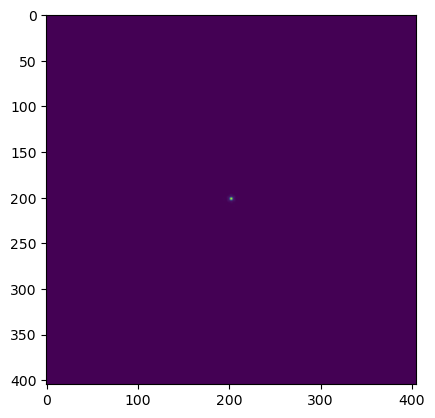

In [9]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])
# has attributes .upper_limit, .psf_photometry, .create_psf_subtracted, .aperature_photometry, .plant_psf

# input_drzs[0] # use this as data and error
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4) # this uses photutils to find PSF

plt.imshow(psf_drz.data)
plt.show()

2915it [00:01, 2157.22it/s, +200 | bound: 18 | nc: 1 | ncall: 12408 | eff(%): 25.516 | loglstar:   -inf < -7.616 <    inf | logz: -20.524 +/-  0.242 | dlogz:  0.001 >  0.209]   


[2.08742417 0.13488385 0.1242565 ]
0.32630144615616946
[0.68112953 0.0440128  0.04054508]
Finished PSF psf_photometry with median residuals of 4.83%


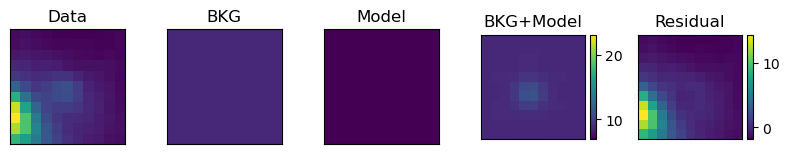

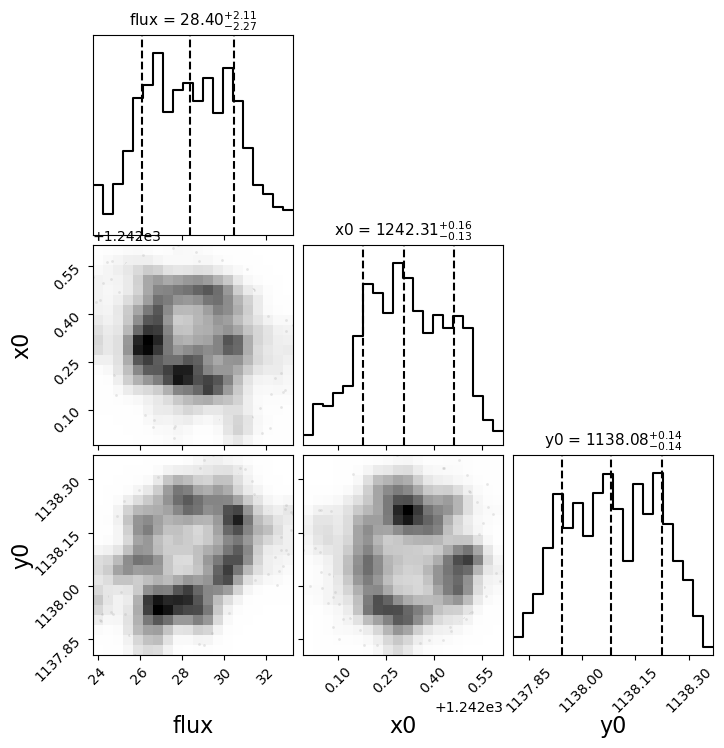

In [15]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 8.75,
                            fit_bkg=False,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [16]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag                magerr      
------------------ -------------------
21.615160893786452 0.07713941290070435


#### Calculate Flux in Janskys

In [17]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  8.202299865458726e-06
FLUX ERROR [Jy] =  5.827572050044736e-07


In [18]:
add_row(filter, flux_jy, flux_err_jy, mag_ab, mag_err, instrument = 'MIRI')

# MIRI F1000W

In [19]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F1000W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F1000W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)
drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()

['F1000W', 'F1000W', 'F1000W', 'F1000W', 'F1000W', 'F1000W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_05101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_05101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00001_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop

### Run PSF fit

2025-12-09 09:34:59,875 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-09 09:34:59,875 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-09 09:34:59,876 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-09 09:34:59,877 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-09 09:34:59,877 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-09 09:34:59,878 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-09 09:34:59,878 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-09 09:34:59,953 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-09 09:34:59,958 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

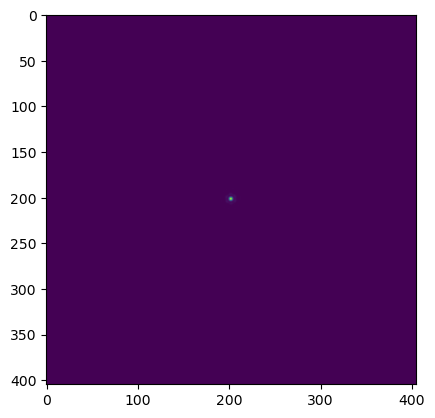

In [20]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])

psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

3270it [00:01, 2283.95it/s, +200 | bound: 20 | nc: 1 | ncall: 13265 | eff(%): 26.560 | loglstar:   -inf < -1.183 <    inf | logz: -15.860 +/-  0.260 | dlogz:  0.001 >  0.209]


[2.49866186 0.0418047  0.04044831]
0.32630144615616946
[0.81531698 0.01364093 0.01319834]
Finished PSF psf_photometry with median residuals of 1.18%


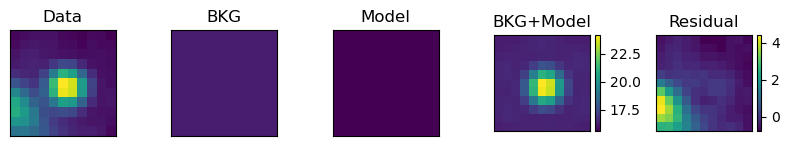

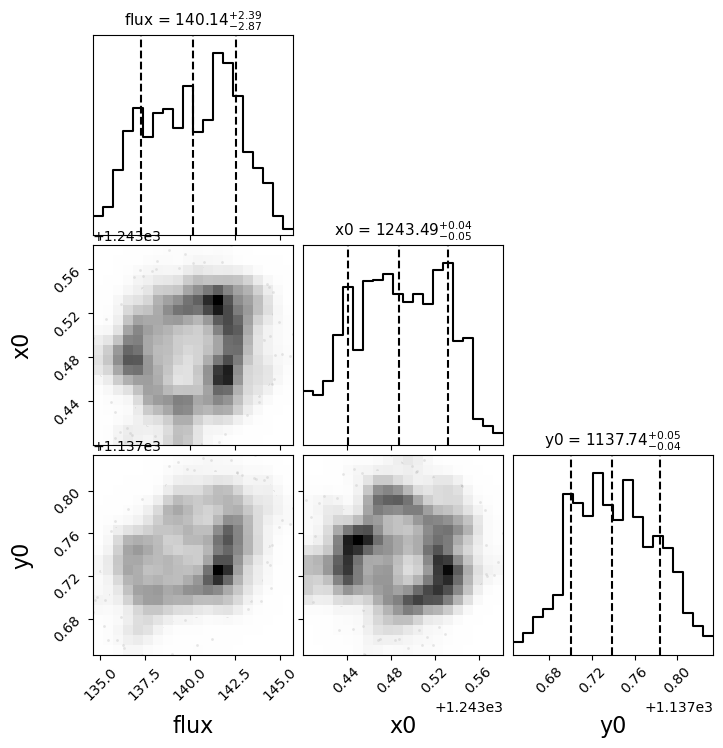

In [23]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 16.25,
                            fit_bkg=False,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [24]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag                magerr       
------------------ --------------------
19.881203892061738 0.019207128498388567


#### Calculate Flux

In [25]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  4.0505914641012626e-05
FLUX ERROR [Jy] =  7.165666061840544e-07


In [26]:
add_row(filter, flux_jy, flux_err_jy, mag_ab, mag_err, instrument='MIRI')

# MIRI F1130W

In [27]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F1130W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F1130W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs


['F1130W', 'F1130W', 'F1130W', 'F1130W', 'F1130W', 'F1130W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_07101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_07101_00003_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f1130w_jhat_i2d.fits']

2025-12-09 09:36:12,937 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-09 09:36:12,938 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-09 09:36:12,939 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-09 09:36:12,939 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-09 09:36:12,940 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-09 09:36:12,941 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-09 09:36:12,941 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-09 09:36:13,011 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-09 09:36:13,016 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

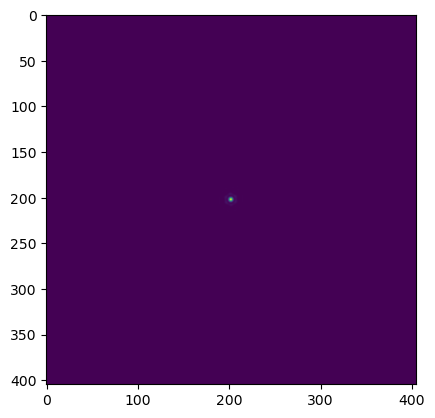

In [28]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

3378it [00:01, 2236.81it/s, +200 | bound: 21 | nc: 1 | ncall: 13526 | eff(%): 26.850 | loglstar:   -inf < -13.734 <    inf | logz: -28.958 +/-  0.265 | dlogz:  0.001 >  0.209]


[3.00390047 0.05471273 0.05336154]
0.32630144615616946
[0.98017707 0.01785284 0.01741195]
Finished PSF psf_photometry with median residuals of 5.24%


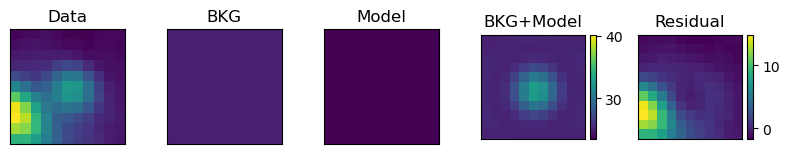

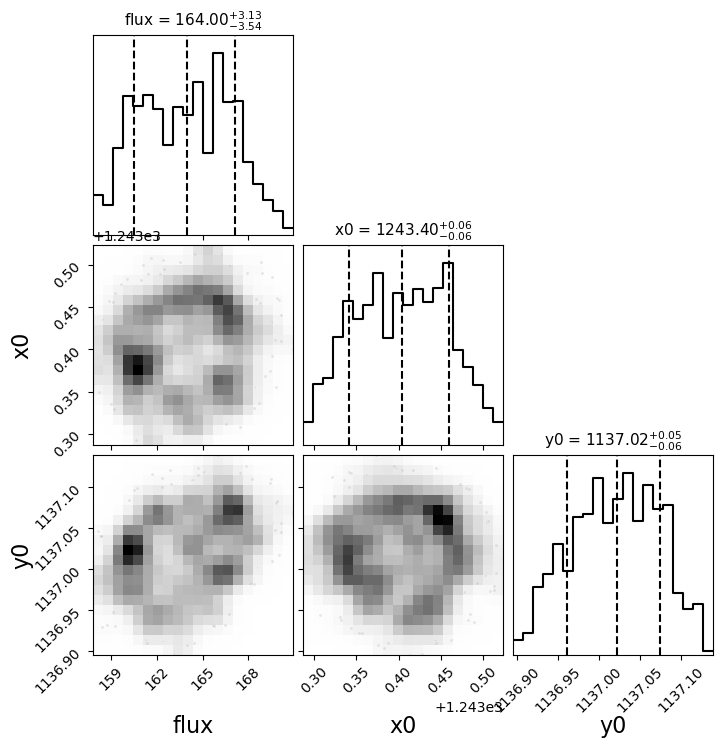

In [31]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 25,
                            fit_bkg=False,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [32]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag                magerr      
------------------ -------------------
19.709470147088343 0.01970817841597096


#### Calculate Flux

In [33]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  4.744734777895734e-05
FLUX ERROR [Jy] =  8.612596607668877e-07


In [34]:
add_row(filter, flux_jy, flux_err_jy, mag_ab, mag_err, instrument='MIRI')

# MIRI F2100W

In [35]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F2100W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F2100W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)
drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()

['F2100W', 'F2100W', 'F2100W', 'F2100W', 'F2100W', 'F2100W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_09101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_09101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00004_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop

### Run PSF fit

2025-12-09 09:37:27,202 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-09 09:37:27,203 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-09 09:37:27,204 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-09 09:37:27,205 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-09 09:37:27,205 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-09 09:37:27,206 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-09 09:37:27,206 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-09 09:37:27,277 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-09 09:37:27,282 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

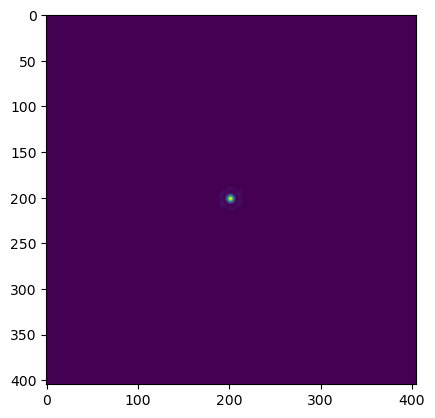

In [36]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])

psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

3106it [00:01, 1991.94it/s, +200 | bound: 22 | nc: 1 | ncall: 13966 | eff(%): 24.016 | loglstar:   -inf < -9.625 <    inf | logz: -23.505 +/-  0.251 | dlogz:  0.001 >  0.209]   


[8.59421243 0.10255811 0.03802529]
0.32630144615616946
[2.80430394 0.03346486 0.01240771]
Finished PSF psf_photometry with median residuals of 0.37%


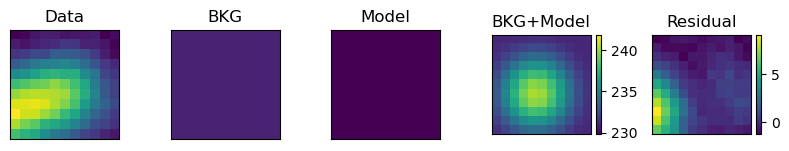

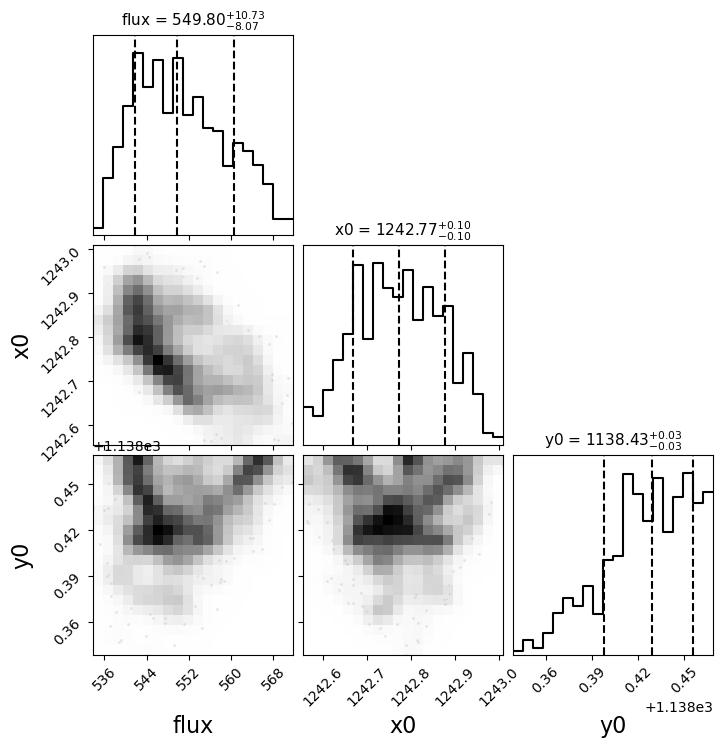

In [40]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 231,
                            fit_bkg=False,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [41]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag                magerr       
------------------ --------------------
18.394250150925902 0.016813556187821915


#### Calculate Flux

In [42]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  0.00015933087443578708
FLUX ERROR [Jy] =  2.4673752224903376e-06


In [43]:
add_row(filter, flux_jy, flux_err_jy, mag_ab, mag_err, instrument = 'MIRI')

## ----------------------------------------------------------------------------------------
## ----------------------------------------------------------------------------------------

# NIRCAM F200W

### Grab files

In [44]:
# SN 1983V
lvl2 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/*_cal.fits'
lvl3 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/*jhat_i2d.fits'
lvl3_single = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f200w_jhat_i2d.fits'

# same as MIRI above
ra  = '3:33:31.6159' #unit=(u.hourangle,u.deg)) #icrs
dec = '-36:08:55.222' #unit=(u.hourangle,u.deg)) #icrs


In [45]:
files = glob.glob(lvl2) #lvl2
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter_arr

['F200W', 'F2100W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F1000W', 'F770W', 'F200W', 'F1000W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F300M', 'F770W', 'F200W', 'F335M', 'F360M', 'F200W', 'F2100W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F1000W', 'F770W', 'F360M', 'F770W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F2100W', 'F360M', 'F1000W', 'F1130W', 'F200W', 'F2100W', 'F200W', 'F1130W', 'F300M', 'F335M', 'F360M', 'F200W', 'F360M', 'F200W', 'F300M', 'F1000W', 'F200W', 'F770W', 'F200W', 'F200W', 'F200W', 'F770W', 'F200W', 'F200W', 'F200W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F200W', 'F2100W', 'F1130W', 'F300M', 'F2100W', 'F1000W', 'F200W', 'F200W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F360M', 'F200W', 'F200W', 'F200W', 'F770W', 'F200W', 'F200W', 'F200W', 'F360M', 'F1000W', 'F200W', 'F200W', 'F200W', 'F335M', 'F1000W', 'F2100W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F335M', 'F200W', 'F200W', 'F360M', 'F200W', 'F1130W', 'F21

['F200W',
 'F2100W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F1000W',
 'F770W',
 'F200W',
 'F1000W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F300M',
 'F770W',
 'F200W',
 'F335M',
 'F360M',
 'F200W',
 'F2100W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F1000W',
 'F770W',
 'F360M',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F2100W',
 'F360M',
 'F1000W',
 'F1130W',
 'F200W',
 'F2100W',
 'F200W',
 'F1130W',
 'F300M',
 'F335M',
 'F360M',
 'F200W',
 'F360M',
 'F200W',
 'F300M',
 'F1000W',
 'F200W',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F2100W',
 'F1130W',
 'F300M',
 'F2100W',
 'F1000W',
 'F200W',
 'F200W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F360M',
 'F200W',
 'F200W',
 'F200W',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F360M',
 'F1000W',
 'F200W',
 'F200W',
 'F200W',
 'F335M',
 'F1000W',
 'F2100W',
 'F200W'

### Centroid

In [46]:
f = fits.open(lvl3_single)
data = f[1].data
w = WCS(f[1].header)

initial_location = SkyCoord(ra,dec,unit=(u.hourangle,u.deg)) #icrs
print(initial_location)

x_init, y_init = wcs.utils.skycoord_to_pixel(initial_location,w)
print(x_init, y_init)

x_cent, y_cent = centroid_sources(data, x_init, y_init, box_size=3, centroid_func=centroid_2dg)
print(x_cent,y_cent)

centered_location = wcs.utils.pixel_to_skycoord(x_cent[0],y_cent[0],w)
print(centered_location)

sn_location = centered_location
print(sn_location)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.38173292, -36.14867278)>
2590.898681841159 5376.109602703007
[2590.85447829] [5375.43462423]
<SkyCoord (ICRS): (ra, dec) in deg
    (53.3817399, -36.14867154)>
<SkyCoord (ICRS): (ra, dec) in deg
    (53.3817399, -36.14867154)>


### Now run through filters

In [47]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F200W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F200W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs



['F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00001_nrcb2_cal.fits',
 '/Users/s

#### Run PSF

2025-12-09 09:39:04,284 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-09 09:39:04,285 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-09 09:39:04,286 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-09 09:39:04,287 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-09 09:39:04,287 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-09 09:39:04,288 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-09 09:39:04,288 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-09 09:39:04,358 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-09 09:39:04,363 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

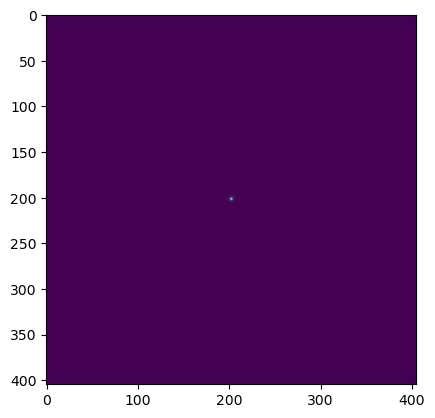

In [48]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

2429it [00:01, 1985.89it/s, +200 | bound: 15 | nc: 1 | ncall: 11163 | eff(%): 23.981 | loglstar:   -inf < -0.583 <    inf | logz: -11.067 +/-  0.216 | dlogz:  0.001 >  0.209]   


[1.29975209 0.50448272 0.48375259]
0.32630144615616946
[0.42411099 0.16461344 0.15784917]
Finished PSF psf_photometry with median residuals of -1.52%


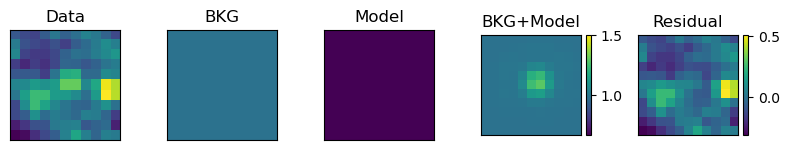

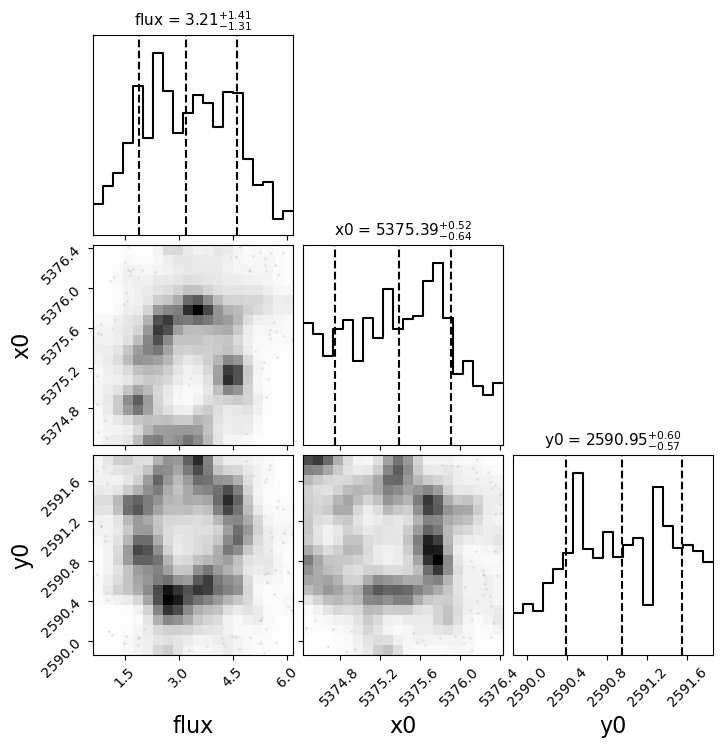

In [53]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 0.98,
                            fit_bkg=False,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [54]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag                magerr      
------------------ -------------------
26.760676656666664 0.36734315684640706


#### Calculate Flux

In [55]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  7.173470841396443e-08
FLUX ERROR [Jy] =  2.427040208179528e-08


In [56]:
add_row(filter, flux_jy, flux_err_jy, mag_ab, mag_err, instrument='NIRCam')

# F300M

In [57]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F300M']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F300M'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs



['F300M', 'F300M', 'F300M', 'F300M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00001_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00003_nrcblong_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f1000w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f2100w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_cle

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00001_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00003_nrcblong_cal.fits']

2025-12-09 09:41:32,509 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-09 09:41:32,510 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-09 09:41:32,511 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-09 09:41:32,511 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-09 09:41:32,512 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-09 09:41:32,512 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-09 09:41:32,513 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-09 09:41:32,584 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-09 09:41:32,589 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

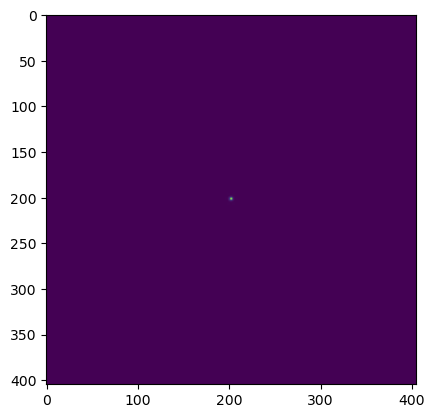

In [58]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

2647it [00:01, 2010.52it/s, +200 | bound: 17 | nc: 1 | ncall: 12042 | eff(%): 24.042 | loglstar:   -inf < -0.098 <    inf | logz: -11.652 +/-  0.229 | dlogz:  0.001 >  0.209]   


[0.84430348 0.51475969 0.53259357]
0.32630144615616946
[0.27549745 0.16796683 0.17378605]
Finished PSF psf_photometry with median residuals of -2.22%


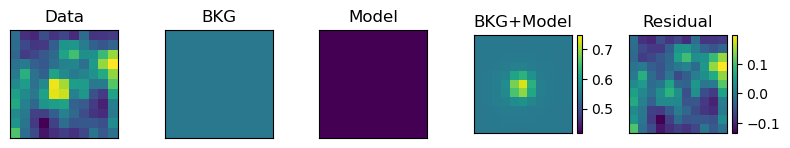

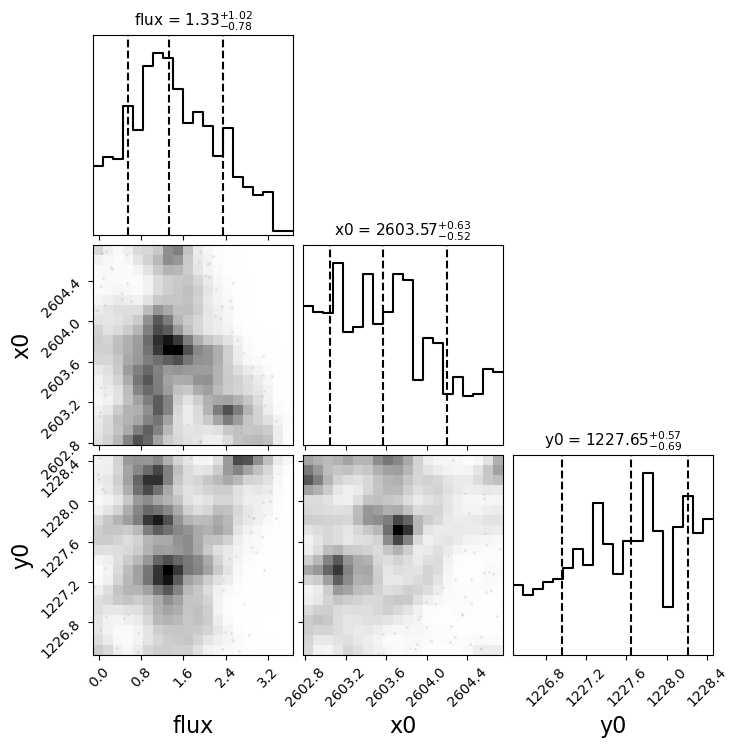

In [60]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 0.55,
                            fit_bkg=False,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [61]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag                magerr      
------------------ -------------------
26.037227795351402 0.48550288557918175


#### Calculate Flux

In [62]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  1.396718488101964e-07
FLUX ERROR [Jy] =  6.245631796596108e-08


In [63]:
add_row(filter, flux_jy, flux_err_jy, mag_ab, mag_err, instrument='NIRCam')

# NIRCAM F335M

In [64]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F335M']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F335M'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs



['F335M', 'F335M', 'F335M', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcblong_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f1000w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f2100w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_cle

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcblong_cal.fits']

2025-12-09 09:42:26,944 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-09 09:42:26,944 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-09 09:42:26,945 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-09 09:42:26,946 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-09 09:42:26,946 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-09 09:42:26,947 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-09 09:42:26,947 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-09 09:42:27,018 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-09 09:42:27,023 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

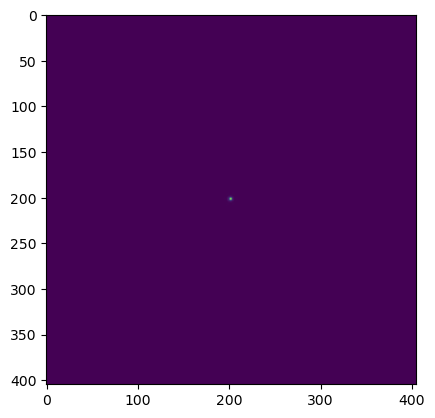

In [65]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

2739it [00:01, 2041.69it/s, +200 | bound: 18 | nc: 1 | ncall: 12130 | eff(%): 24.635 | loglstar:   -inf < -0.620 <    inf | logz: -12.645 +/-  0.234 | dlogz:  0.001 >  0.209]   


[0.74790761 0.36868133 0.31793378]
0.32630144615616946
[0.24404334 0.12030125 0.10374225]
Finished PSF psf_photometry with median residuals of 6.27%


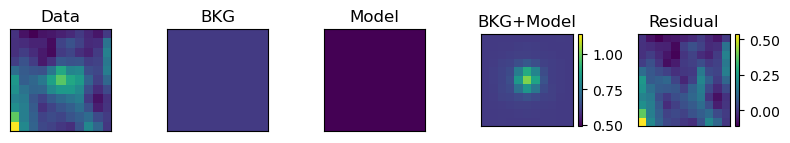

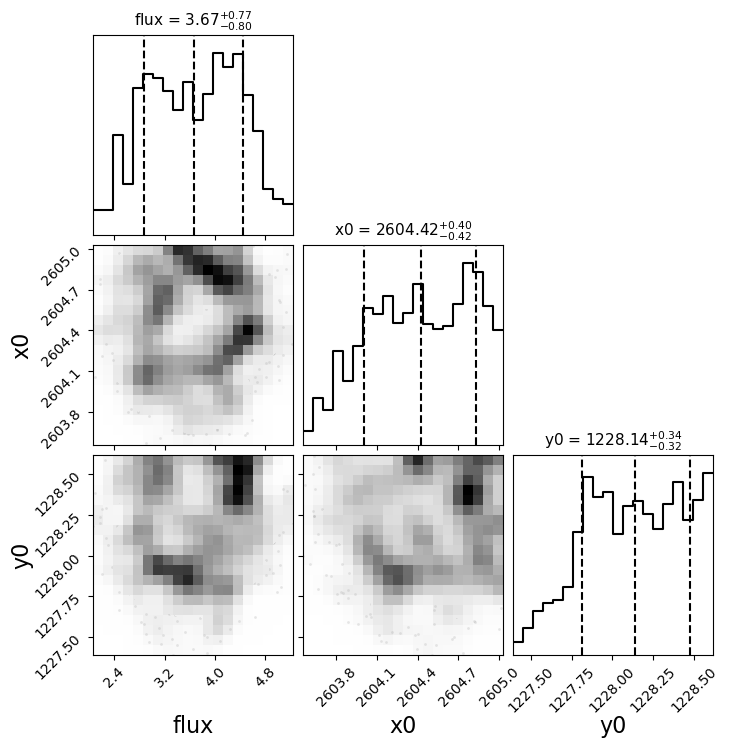

In [71]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 0.6,
                            fit_bkg=False,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [72]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag               magerr      
------------------ ------------------
25.072793284208977 0.2028934554203391


#### Calculate Flux

In [73]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  3.395335437919429e-07
FLUX ERROR [Jy] =  6.344923714357193e-08


In [74]:
add_row(filter, flux_jy, flux_err_jy, mag_ab, mag_err, instrument='NIRCam')

# NIRCAM F360M

In [75]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F360M']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F360M'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs


['F360M', 'F360M', 'F360M', 'F360M', 'F360M', 'F360M', 'F360M', 'F360M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00001_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00003_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcblong_cal.fits']
['F300M', 'F1000W', 'F2100W', 

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00001_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00003_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcblong_cal.fits']

2025-12-09 09:43:46,594 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-09 09:43:46,595 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-09 09:43:46,596 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-09 09:43:46,597 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-09 09:43:46,598 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-09 09:43:46,598 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-09 09:43:46,599 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-09 09:43:46,679 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-09 09:43:46,685 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

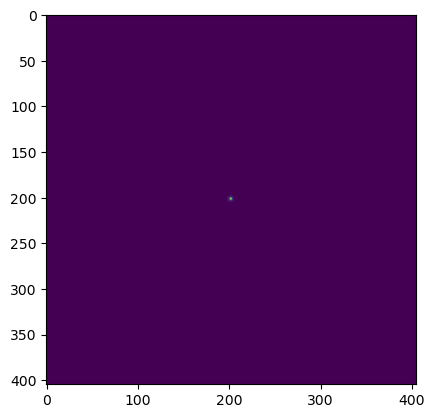

In [76]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

2610it [00:01, 2028.33it/s, +200 | bound: 16 | nc: 1 | ncall: 12063 | eff(%): 23.687 | loglstar:   -inf < -0.271 <    inf | logz: -11.654 +/-  0.227 | dlogz:  0.001 >  0.209]   


[1.1682033  0.46884814 0.44596959]
0.32630144615616946
[0.38118643 0.15298583 0.14552052]
Finished PSF psf_photometry with median residuals of 6.46%


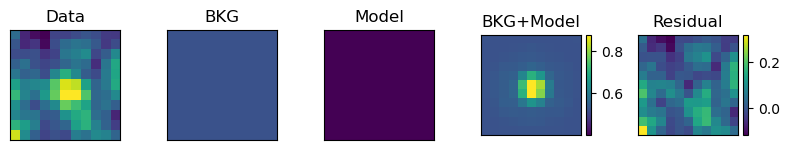

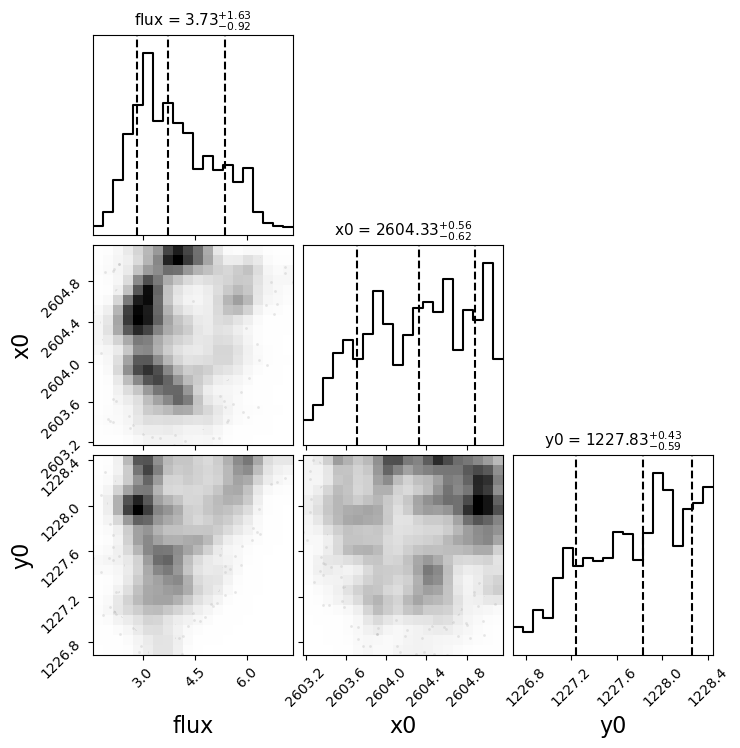

In [79]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 0.52,
                            fit_bkg=False,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [80]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag               magerr     
------------------ -----------------
24.964211934612347 0.276819430316828


#### Calculate Flux

In [81]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  3.7524526959029124e-07
FLUX ERROR [Jy] =  9.567257801834964e-08


In [82]:
add_row(filter, flux_jy, flux_err_jy, mag_ab, mag_err, instrument='NIRCam')

# SED

{'Filter': ['F770W', 'F1000W', 'F1130W', 'F2100W', 'F200W', 'F300M', 'F335M', 'F360M'], 'Flux': [np.float64(8.202299865458726e-06), np.float64(4.0505914641012626e-05), np.float64(4.744734777895734e-05), np.float64(0.00015933087443578708), np.float64(7.173470841396443e-08), np.float64(1.396718488101964e-07), np.float64(3.395335437919429e-07), np.float64(3.7524526959029124e-07)], 'Flux_err': [np.float64(5.827572050044736e-07), np.float64(7.165666061840544e-07), np.float64(8.612596607668877e-07), np.float64(2.4673752224903376e-06), np.float64(2.427040208179528e-08), np.float64(6.245631796596108e-08), np.float64(6.344923714357193e-08), np.float64(9.567257801834964e-08)], 'Mag': [np.float64(21.615160893786452), np.float64(19.881203892061738), np.float64(19.709470147088343), np.float64(18.394250150925902), np.float64(26.760676656666664), np.float64(26.037227795351402), np.float64(25.072793284208977), np.float64(24.964211934612347)], 'Mag_err': [np.float64(0.07713941290070435), np.float64(0.0

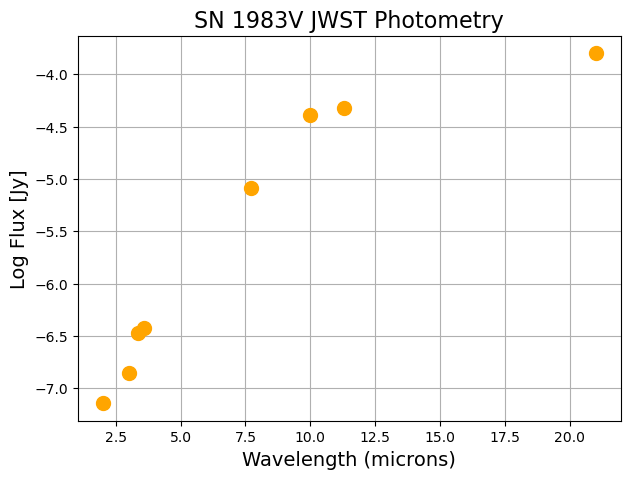

In [ ]:
# print Phot table
print(phot_table)
waves = [7.7,10,11.3,21,2,3,3.35,3.6]
# plot SED from table
plt.figure(figsize=(7,5))
plt.xlabel('Wavelength (microns)', fontsize=14)
plt.ylabel('Log Flux [Jy]', fontsize=14)
plt.title('SN 1983V JWST Photometry', fontsize=16)
plt.grid()

for i in range(len(phot_table['Filter'])):
    
    plt.plot(waves[i], np.log10(phot_table['Flux'][i]), marker='o', markersize=10, color='orange')


## Save photometry table in format used for dustysn!

In [102]:
# write table to .csv stored in current directory, to be used in dustysn
# rearrange phot table to use structure:
# Flux, Flux_err, UL, Filter, Telescope, Instrument
COLUMNS = ["Flux", "Flux_err", "UL", "Filter", "Telescope", "Instrument"]

param_table = {c: [] for c in COLUMNS}

for i in range(len(phot_table['Filter'])):
    param_table["Flux"].append(phot_table['Flux'][i])
    param_table["Flux_err"].append(phot_table['Flux_err'][i])
    param_table["UL"].append(False)
    param_table["Filter"].append(phot_table['Filter'][i])
    param_table["Telescope"].append('JWST')
    param_table["Instrument"].append(phot_table['Instrument'][i])


import pandas as pd

# Convert dict to DataFrame
df = pd.DataFrame(param_table)

# Save as tab-delimited .txt
df.to_csv("83V_photometry_table.txt", sep="\t", index=False)

